In [1]:
import geopandas as gpd
from shapely.ops import polygonize
import shapely
import io
import csv
from shapely import Point
from shapely.plotting import plot_polygon, plot_points
import os
import numpy as np
import math
import pandas as pd
from shapely.geometry import LineString, MultiLineString, MultiPolygon
from shapely.ops import unary_union
from shapely.ops import linemerge
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter
from scipy import stats

In [2]:
# Project ICESAT-2 ridge points
def read_points(file_name, points, elevations):
    with io.open(file_name, mode="r", encoding="utf-8") as f:
        for line in f.readlines():
            tmp = line.split(',')
            if len(tmp) == 4:
                points.append(Point(tmp[0], tmp[1]))
                elevations.append(float(tmp[3]))
    return points, elevations

In [3]:
def read_oib_points(file_name):
    with io.open(file_name, mode="r", encoding="utf-8") as f:
        points = []
        elevations = []
        for line in f.readlines():
            tmp = line.split()
            if len(tmp) == 3:
                points.append(Point(tmp[0], tmp[1]))
                elevations.append(float(tmp[2]))
    return points, elevations

In [4]:
def read_ridge_peak_points(file_name, points, stats):
    with io.open(file_name, mode="r", encoding="utf-8") as f:
        next(f)
        for line in f:
            tmp = line.split(',')
            points.append(Point(tmp[0], tmp[1]))
            stats.append([float(tmp[2]), float(tmp[3]), float(tmp[4])])
    return points, stats

In [5]:
def read_qgis_exported_csv(file_name):
    with io.open(file_name, mode="r", encoding="utf-8") as f:
        geometries = []
        orig_ids = []
        next(f)
        for line in f:
            tmp = line.split('\"')
            geometry = shapely.wkt.loads(tmp[1])
            
            if not geometry.is_empty:
                geometries.append(geometry)
                orig_ids.append(tmp[3])
        return geometries, orig_ids

In [32]:
def write_point_vtk(file_name, points, elevations):
    with io.open(file_name, mode="w", encoding="utf-8") as f:
        f.write("# vtk DataFile Version 2.0\n\n")
        f.write("ASCII \n")
        f.write("DATASET UNSTRUCTURED_GRID\n\n")
        f.write("POINTS " + str(len(points)) + " float\n")
        for point,elevation in zip(points, elevations):
            f.write('{:.8f}'.format(point.x) + " " + '{:.8f}'.format(point.y) + " " + '{:.8f}'.format(elevation) +"\n")
        f.write("\n\n")
        f.write("POINT_DATA " + str(len(points)) +"\n")
        f.write("FIELD FieldData 1\n")
        f.write("elevation 1 " + str(len(points)) + " float\n")
        for elevation in elevations:
            f.write(str(elevation)+ " ")


In [10]:
def project_distance(row,  icesat2_path):
    return icesat2_path.project(Point(row.x, row.y))

In [9]:
def read_ridge_tri_wkt(file_name):
    tris = []
    with io.open(file_name, mode="r", encoding="utf-8") as f:
        next(f)
        for line in f:
            parts = line.split('\"')
            geometry = shapely.wkt.loads(parts[1])
            tris.append(geometry)
    return tris

In [8]:
def project_distance_gdf(row, icesat2_path):
    return icesat2_path.project(row.geometry)


In [7]:
# when select_only_peaks is True, edges below 0.6m relative height are excluded. This is used when comparing to the results from ICESat-2 ridges
def read_ridge_lines_wkt(file_name, select_only_peaks):
    ridges_elev = []
    rid = []
    features = []
    with io.open(file_name, mode="r", encoding="utf-8") as f:
        next(f)
        for line in f:
            parts = line.split('\"')
            info = parts[2].split(',')
            top = max(float(info[1]), float(info[2]))
            ridge_id = int(info[3])
            if select_only_peaks and top < 0.6:
                continue
            wkt = parts[1]
            # wkt = parts[1].replace(', )', ')') # error in format casued by the early version of writer in C++ code.
            geometry = shapely.wkt.loads(wkt)
            features.append(geometry)
            rid.append(ridge_id)

    ridges = gpd.GeoDataFrame({"feature": features, 'ridge id': rid} ,crs = "EPSG:3411", geometry='feature')
    return ridges

In [11]:
def read_space_delimited_points(file_name):
    points = []
    with io.open(file_name, mode="r", encoding="utf-8") as f:
        for line in f.readlines():
            tmp = line.split(' ')
            if len(tmp) == 3:
                points.append([float(tmp[0]), float(tmp[1]), float(tmp[2])])
    return points

In [42]:
def generate_ridge_line_file_name(persistence, length, roughness, use_roughness, part_name):
    version = "v3"
    if use_roughness:
        return "/Users/robo/data/leg6_processed/ridges_"+part_name+"_v4/leg6_projected_ridges_region_"+part_name+"_v2_as_20.000000_after_"+persistence+"_l"+length+"_roughness_filtered_r"+roughness+"_Rayleigh_enabled_kv_255_asc1cells_filtered_ridge_lines_wkt.csv"
    else:
        return "/Users/robo/data/leg6_processed/ridges_"+part_name+"_v4/leg6_projected_ridges_region_"+part_name+"_v2_as_20.000000_after_"+persistence+"_l"+length+"_Rayleigh_enabled_kv_200_asc1cells_filtered_ridge_lines_wkt.csv"


In [43]:
def generate_ridge_peak_file_name(persistence, length, roughness, use_roughness, part_name):
    if use_roughness:
        return "/Users/robo/data/leg6_processed/ridges_"+part_name+"_v4/leg6_projected_ridges_region_"+part_name+"_v2_as_20.000000_after_"+persistence+"_l"+length+"_roughness_filtered_r"+roughness+"_Rayleigh_enabled_ridges.csv"
    else:
        return "/Users/robo/data/leg6_processed/ridges_"+part_name+"_v4/leg6_projected_ridges_region_"+part_name+"_v2_as_20.000000_after_"+persistence+"_l"+length+"_Rayleigh_enabled_ridges.csv"


In [41]:
def evaluate_ridge_results_old(ridges, icesat2_ridges, icesat2_path):
    ridge_lines =  MultiLineString(ridges)
    merged_ridges =  list(linemerge(ridge_lines).geoms)
    minx, miny, maxx, maxy = ridge_lines.bounds
    
    part1_ridges = icesat2_ridges.cx[minx:maxx, miny:maxy]
    buffered = part1_ridges.buffer(5)
    icebridge_results = buffered.intersection(ridge_lines)
    print( icebridge_results[icebridge_results.is_empty == True])
    icebridge_results = icebridge_results[icebridge_results.is_empty == False]
    
    print(len(icebridge_results))
    print(len(part1_ridges))
    recall = len(icebridge_results)/len(part1_ridges)
    print("recall: " + str(recall))
    intersections = []
    FP = []
    for ridge in merged_ridges:
        intersection = shapely.intersection(icesat2_path, ridge.buffer(5))
        if intersection.is_empty == False:
            intersections.append(intersection)
            ridge_peak_intersect = buffered.intersection(ridge)
            ridge_peak_intersect = ridge_peak_intersect[ridge_peak_intersect.is_empty == False]
            if len(ridge_peak_intersect) == 0:
                FP.append(ridge)
            
    # one item in merged_ridges is one separate ridge extracted from ATM
    # so the size of intersections before merging is the number of ridges intersecting with ICESat-2 track
    print(len(merged_ridges))
    print(len(intersections))
    print(len(FP))
    result = unary_union(intersections)
    merged_result = list(linemerge(result).geoms)
    type(linemerge(result).geoms)
    print(len(merged_result))
    precision = len(icebridge_results)/(len(FP) +  len(icebridge_results)) 
    print("precision: " + str(precision))
    return [recall, precision, len()]
    

In [44]:
def evaluate_ridge_results(ridges, icesat2_ridges, icesat2_path):
    icesat2_path_range = icesat2_path.buffer(5)
    oib_in_range = ridges.clip(icesat2_path_range)
    total_ridges_in_range = oib_in_range['ridge id'].nunique()
    print(total_ridges_in_range)

    buffered_ridges = icesat2_ridges.copy(deep = True)
    buffered_ridges.geometry = icesat2_ridges.geometry.buffer(5)
    # buffered_ridges.set_geometry('feature')  
    join_left_df = buffered_ridges.sjoin(oib_in_range, how="left")
    join_left_df = join_left_df.dropna()
    matched_in_oib = len(join_left_df['ridge id'].unique())
    total_ridges_in_range = oib_in_range['ridge id'].nunique()
    TP = join_left_df.index.nunique()
    FN = list(set(icesat2_ridges.index) - set(join_left_df.index.unique()))
    FN.sort()
    print(FN)
    recall = TP/len(icesat2_ridges)
    print("recall: " + str(recall))
    precision = matched_in_oib/total_ridges_in_range
    print("precision: " + str(precision))
    return [recall, precision, len(icesat2_ridges), TP, total_ridges_in_range ] #, icebridge_peaks
    

In [8]:
def compare_ridge_lines(oib_ridges, visual_ridges, compare_range):
    clipped_oib_ridges = oib_ridges.clip(compare_range)
    print(clipped_oib_ridges['ridge id'].nunique())
    oib_ridge_buffer = clipped_oib_ridges.geometry.buffer(2)
    oib_ridge_buffer_pl = MultiPolygon(oib_ridge_buffer.unary_union)
    matched = checked_ridges_gdf.clip(oib_ridge_buffer_pl)
    matched = matched.dropna()
    checked_ridges_gdf['length'] = checked_ridges_gdf.geometry.length
    print(checked_ridges_gdf['length'].sum())
    matched['length'] = matched.geometry.length
    clipped_oib_ridges['length'] = clipped_oib_ridges.geometry.length
    TP = len(matched)
    print(len(checked_ridges_gdf) - TP)
    FN = list(set(checked_ridges_gdf.index) - set(matched.index))
    FN.sort()
    print(checked_ridges_gdf.iloc[FN, :].orig_ids)
    print(clipped_oib_ridges['ridge id'].nunique())
    recall = TP/len(checked_ridges_gdf)
    print("recall: " + str(recall))
    print("total num of ridges detected from ATM: " + str(len(clipped_oib_ridges)))
    return [TP, clipped_oib_ridges['ridge id'].nunique(), matched['length'].sum(), checked_ridges_gdf['length'].sum(), clipped_oib_ridges['length'].sum()]


In [12]:
def read_boundary_lines(file_name):
    edges = []
    with io.open(file_name, mode="r", encoding="utf-8") as f:
        total = 0
        for line in f:
            geometry = shapely.wkt.loads(line)
            edges.append(geometry)
    return edges

In [21]:
def oib_icesat_intersect(ridges, icesat2_ridges, icesat2_path):
    icesat2_path_range = icesat2_path.buffer(0.1)
    oib_in_range = ridges.clip(icesat2_path_range)
    oib_in_range.dropna()
    ridge_lines = unary_union(list(oib_in_range.geometry))
    merged_ridges =  list(linemerge(ridge_lines).geoms)
    result = gpd.GeoSeries(merged_ridges)
    # centroids = merged_result.centroid
    centroids = result.interpolate(0.5, normalized = True)
    centroids_df = gpd.GeoDataFrame(centroids, geometry = centroids, crs = "EPSG:3411")
    return centroids_df 

In [51]:
points = []
elevations = []
points, elevations = read_oib_points("/Users/robo/data/leg6_processed/leg6_projected_v2.txt")

In [53]:
gdf = gpd.GeoDataFrame({'elevation':elevations, 'geometry':points}, crs='epsg:3411', geometry = points) 

In [54]:
xmin, ymin, xmax, ymax = gdf.total_bounds
leg6_v3 = gdf.cx[xmin : xmax, ymin:-417450]

# Project ridges and write results to files

In [55]:
projected_leg6 = gdf.to_crs(epsg=3411)

In [6]:
xmin, ymin, xmax, ymax = projected_leg6.total_bounds

In [56]:
y1_max = -425750
y1_min = y1_max - 24500
y2_max = y1_max - 24000
y2_min = y2_max - 24500
y3_max = y2_max - 24000
y3_min = -497750

In [44]:
leg6_v3 =projected_leg6.cx[xmin:xmax, y3_min:y1_max]

In [57]:
leg6_part1 = projected_leg6.cx[xmin:xmax, y1_min:y1_max]
leg6_part2 = projected_leg6.cx[xmin:xmax, y2_min:y2_max]
leg6_part3 = projected_leg6.cx[xmin:xmax, y3_min:y3_max]

In [19]:
with io.open("/Users/robo/data/leg6_processed/leg6_projected_v3.txt", mode="w", encoding="utf-8") as f:
    for point, elevation in zip(leg6_v3['geometry'], leg6_v3['elevation']):
        f.write(str(point.x) + " " + str(point.y)+ " " + str(elevation)+"\n")

In [58]:
ele_mode1 = leg6_part1['elevation'].round(2).mode()
print(ele_mode1)

0   -0.31
Name: elevation, dtype: float64


In [56]:
ele_mode2 = leg6_part2['elevation'].round(2).mode()
print(ele_mode2)

0   -0.3
Name: elevation, dtype: float64


In [55]:
ele_mode3 = leg6_part3['elevation'].round(2).mode()
print(ele_mode3)

0   -0.22
Name: elevation, dtype: float64


In [59]:
with io.open("/Users/robo/data/leg6_processed/leg6_projected_ridges_region_part1_v2.txt", mode="w", encoding="utf-8") as f:
    f.write("x, y, z\n")
    for point, elevation in zip(leg6_part1['geometry'], leg6_part1['elevation']):
        f.write(str(point.x) + ", " + str(point.y)+ ", " + str(elevation)+"\n")

In [63]:
with io.open("/Users/robo/data/leg6_processed/leg6_projected_ridges_region_part2_v2.txt", mode="w", encoding="utf-8") as f:
    for point, elevation in zip(leg6_part2['geometry'], leg6_part2['elevation']):
        f.write(str(point.x) + " " + str(point.y)+ " " + str(elevation)+"\n")

In [64]:
with io.open("/Users/robo/data/leg6_processed/leg6_projected_ridges_region_part3_v2.txt", mode="w", encoding="utf-8") as f:
    for point, elevation in zip(leg6_part3['geometry'], leg6_part3['elevation']):
        f.write(str(point.x) + " " + str(point.y)+ " " + str(elevation)+"\n")

In [15]:
df = pd.DataFrame(elevations, columns = ['elevation'])

In [16]:
ele_mode = df['elevation'].round(2).mode()

In [65]:
print(ele_mode)

0   -0.28
Name: elevation, dtype: float64


In [29]:
ridge_range, ids = read_qgis_exported_csv("/Users/robo/data/ridge_visual_range.csv")
visual_checked_ridges, ridge_ids = read_qgis_exported_csv("/Users/robo/data/ridge_visual_selected_new.csv")
ridge_range_gdf = gpd.GeoDataFrame(crs = 'epsg:3411', geometry = ridge_range)
checked_ridges_gdf = gpd.GeoDataFrame({"orig_ids": ridge_ids, "feature": visual_checked_ridges}, crs = 'epsg:3411', geometry = visual_checked_ridges)

In [3]:
ridges = read_ridge_lines_wkt(generate_ridge_line_file_name("0.25", "0", "0.02", True, "part3_v2"), False)
visual_res = compare_ridge_lines(ridges, checked_ridges_gdf, ridge_range_gdf)

NameError: name 'generate_ridge_line_file_name' is not defined

In [45]:
# Read ridege results with given parameters
persistence = '0.25'
length = '0'
roughness = '0.09'
part1_name = generate_ridge_line_file_name(persistence, length, roughness, True, "part1")
ridge_part1 = read_ridge_lines_wkt(part1_name, False)
part2_name = generate_ridge_line_file_name(persistence, length, roughness, True, "part2")
ridge_part2 = read_ridge_lines_wkt(part2_name, False)
part3_name = generate_ridge_line_file_name(persistence, length, roughness, True, "part3")
ridge_part3 = read_ridge_lines_wkt(part3_name, False)
ridges = pd.concat([ridge_part1, ridge_part2, ridge_part3], ignore_index=True)

In [51]:
len(merged_ridges)

1034

In [50]:
result = gpd.GeoSeries(merged_ridges)
# centroids = merged_result.centroid
centroids = result.interpolate(0.5, normalized = True)
centroids_df = gpd.GeoDataFrame(centroids, geometry = centroids, crs = "EPSG:3411")


In [52]:
centroids_df['x'] = centroids_df.geometry.x
centroids_df['y'] = centroids_df.geometry.y


In [53]:
with io.open("/Users/robo/data/leg6_processed/oib_peaks_p025_r009.txt", mode="w", encoding="utf-8") as f:
    f.write(str(len(centroids_df)) + "\n")
    for index, row in centroids_df.iterrows():
        f.write(str(row.x) + " " + str(row.y)+ "\n")


In [137]:
clipped_oib_ridges['length'] = clipped_oib_ridges.geometry.length

In [139]:
clipped_oib_ridges['length'].sum()

35551.08204609691

In [152]:
res = compare_ridge_lines(ridges, checked_ridges_gdf,ridge_range_gdf )

11969.168720815436
320
0        1
1        2
2        4
3        5
4        6
      ... 
475    654
476    655
477    656
478    657
479    658
Name: orig_ids, Length: 320, dtype: object
321
recall: 0.3333333333333333
total num of ridges detected from ATM: 10849


In [153]:
res

[160, 321, 2497.1343257263397, 11969.168720815436, 15878.200421364436]

## Read ridge results from UMD-RDA method

In [18]:
ridge_file = "/Users/robo/data/icesat2/UMDRDA_ATL03_20190909145324_11230404_005_01_gt3r_DriftCorrected_RIDGES_ReltoGeoid.txt"
points = []
elevations = []
points, elevations = read_points(ridge_file, points, elevations)
gdf = gpd.GeoDataFrame({'elevation':elevations, 'geometry':points}, crs='epsg:4326', geometry = points) 
icesat2_ridges = gdf.to_crs(epsg=3411)

In [19]:
file_name = "/Users/robo/data/leg6_processed/leg6_projected_v2_as_25000.000000_boundary_wkt.txt"
edges = read_boundary_lines(file_name)
polygon = polygonize(edges)
region_boundary = gpd.GeoDataFrame( crs='epsg:3411', geometry = list(polygon)) 

In [20]:
clipped_icesat2_ridges = icesat2_ridges.clip(region_boundary.geometry.buffer(-0.5))

In [13]:
file = "/Users/robo/data/icesat2/UMDRDA_ATL03_20190909145324_11230404_005_01_gt3r_DriftCorrected_FINAL_ReltoGeoid_NEW.txt"
points = []
elevations = []
points, elevations = read_points(file, points, elevations)
gdf = gpd.GeoDataFrame(crs='epsg:4326', geometry = points) 
projected_icesat2_path = gdf.to_crs(epsg=3411)

In [22]:
icesat2_path = LineString(projected_icesat2_path['geometry'].tolist())
clipped_icesat2_ridges['distance'] = clipped_icesat2_ridges.apply(project_distance_gdf,icesat2_path=icesat2_path, axis = 1)


/Users/robo/miniconda3/envs/jupyter_nb/lib/python3.10/site-packages/geopandas/geodataframe.py:1538: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [81]:
intersections = oib_icesat_intersect(ridges, clipped_icesat2_ridges, icesat2_path)

In [49]:
icesat2_path_range = icesat2_path.buffer(0.1)
oib_in_range = ridges.clip(icesat2_path_range)
oib_in_range.dropna()
ridge_lines = unary_union(list(oib_in_range.geometry))
merged_ridges =  list(linemerge(ridge_lines).geoms)


In [26]:
ridge_file = "/Users/robo/data/leg6_processed/leg6_projected_v2_as_20.000000_oib_p025_r008_interpolation.txt"
points = []
elevations = []
points, elevations = read_oib_points(ridge_file)
oib_intersections = gpd.GeoDataFrame({'elevation':elevations, 'geometry':points}, crs='epsg:3411', geometry = points) 
# icesat2_ridges = gdf.to_crs(epsg=3411)

In [12]:
len(icesat2_ridges)

400

In [13]:
len(clipped_icesat2_ridges)

378

In [37]:
oib_intersections['distance'] = oib_intersections.apply(project_distance_gdf,icesat2_path=icesat2_path, axis = 1)

# read track points (both ICESat2 and ice bridge)

In [25]:
ice_sat2_points= read_space_delimited_points("/Users/robo/data/icesat2/leg6_projected_relToGeoid.txt")
icebridge_points = read_space_delimited_points("/Users/robo/data/icesat2/leg6_projected_v2_as_25000.000000_icesat2__interpolation.txt")

In [39]:
df_icesat2 = pd.DataFrame(ice_sat2_points, columns = ['x', 'y','z'])
df_icesat2['distance'] = df_icesat2.apply(project_distance,icesat2_path=icesat2_path, axis = 1)
df_icesat2['dataset'] = 'ICESat-2'

In [26]:
df_icebridge = pd.DataFrame(icebridge_points, columns = ['x', 'y','z'])
df_icebridge['distance'] = df_icebridge.apply(project_distance,icesat2_path=icesat2_path, axis = 1)
df_icebridge['dataset'] = 'OIB ATM-TIN'

KeyboardInterrupt: 

In [41]:
df = pd.concat([df_icebridge, df_icesat2], ignore_index=True)

# Read ridge line file and evaluate results

In [42]:
stats, icebridge_peaks = evaluate_ridge_results(ridges, icesat2_ridges, icesat2_path)

NameError: name 'ridges' is not defined

In [44]:
# Results when roughness filter is not considered
persistences = ["0", "0.05", "0.1", "0.15", "0.2", "0.25", "0.3", "0.35", "0.4", "0.45", "0.5"]
evaluation_stats = pd.DataFrame(columns=['persistence', 'length','recall', 'precision', 
                                         'ridge num in ICESat-2', 'matched num', 'ridge num in OIB', 
                                         'visual range matched', 'visual range OIB total','visual range matched length', 
                                         'visual range ridge length', 'visual range OIB length'])
length = "0"
for persistence in persistences:
    part1_name = generate_ridge_line_file_name(persistence, length, 0, False, "part1")
    ridge_part1 = read_ridge_lines_wkt(part1_name, False)
    part2_name = generate_ridge_line_file_name(persistence, length, 0, False, "part2")
    ridge_part2 = read_ridge_lines_wkt(part2_name, False)
    ridge_part2['ridge id'] = ridge_part2['ridge id'] + ridge_part1['ridge id'].max() + 1
    part3_name = generate_ridge_line_file_name(persistence, length, 0, False, "part3")
    ridge_part3 = read_ridge_lines_wkt(part3_name, False)
    ridge_part3['ridge id'] = ridge_part3['ridge id'] + ridge_part2['ridge id'].max() + 1
    ridges = pd.concat([ridge_part1, ridge_part2, ridge_part3], ignore_index=True)
    stats = evaluate_ridge_results(ridges, clipped_icesat2_ridges, icesat2_path)
    visual_res = compare_ridge_lines(ridges, checked_ridges_gdf, ridge_range_gdf)
    
    evaluation_stats.loc[len(evaluation_stats)]=[persistence, length] + stats + visual_res
        
        

1665
[49, 54, 78, 113, 115, 131, 136, 144, 167, 168, 171, 172, 173, 175, 177, 178, 179, 182, 183, 184, 187, 191, 204, 205, 210, 213, 216, 244, 245, 250, 252, 265, 273, 274, 275, 276, 290, 296, 303, 317, 319, 344, 347, 351, 354, 355, 359, 381, 392]
recall: 0.8703703703703703
precision: 0.28348348348348346
1154
11969.168720815436
4
198    331
199    332
385    562
443    620
Name: orig_ids, dtype: object
1154
recall: 0.9916666666666667
total num of ridges detected from ATM: 48397
1674
[49, 54, 70, 75, 78, 113, 115, 136, 144, 157, 167, 168, 171, 172, 173, 175, 177, 178, 179, 182, 184, 185, 191, 195, 202, 204, 205, 211, 213, 216, 217, 229, 235, 245, 250, 252, 265, 274, 276, 296, 303, 317, 319, 344, 347, 351, 354, 355, 358, 389]
recall: 0.8677248677248677
precision: 0.27956989247311825
1141
11969.168720815436
5
198    331
199    332
346    520
358    534
385    562
Name: orig_ids, dtype: object
1141
recall: 0.9895833333333334
total num of ridges detected from ATM: 42335
1689
[49, 54, 70, 75

In [46]:
persistences = ["0", "0.05", "0.1", "0.15", "0.2", "0.25", "0.3", "0.35", "0.4", "0.45", "0.5"]
lengths = ["0", "5","10"] 
roughnesses = ["0.01", "0.02", "0.03", "0.04","0.05", "0.06", "0.07", "0.08"]
length = "0"
persistence_array = []
length_array = []
roughness_array = []
recall = []
precision = []
ridge_num_icesat = []
matched_num = []
ridge_num_OIB = []
visual_matched = []
visual_total = []
visual_matched_length = []
visual_ridge_length = []
visual_OIB_length = []
for persistence in persistences:
    for roughness in roughnesses:
        part1_name = generate_ridge_line_file_name(persistence, length, roughness, True, "part1")
        ridge_part1 = read_ridge_lines_wkt(part1_name, False)
        part2_name = generate_ridge_line_file_name(persistence, length, roughness, True, "part2")
        ridge_part2 = read_ridge_lines_wkt(part2_name, False)
        ridge_part2['ridge id'] = ridge_part2['ridge id'] + ridge_part1['ridge id'].max() + 1
        part3_name = generate_ridge_line_file_name(persistence, length, roughness, True, "part3")
        ridge_part3 = read_ridge_lines_wkt(part3_name, False)
        ridge_part3['ridge id'] = ridge_part3['ridge id'] + ridge_part2['ridge id'].max() + 1
        ridges = pd.concat([ridge_part1, ridge_part2, ridge_part3], ignore_index=True)
        stats  = evaluate_ridge_results(ridges, clipped_icesat2_ridges, icesat2_path)
        visual_res = compare_ridge_lines(ridges, checked_ridges_gdf, ridge_range_gdf)
        persistence_array.append(persistence)
        length_array.append(length)
        roughness_array.append(roughness)
        recall.append(stats[0])
        precision.append(stats[1])
        ridge_num_icesat.append(stats[2])
        matched_num.append(stats[3])
        ridge_num_OIB.append(stats[4])
        visual_matched.append(visual_res[0])
        visual_total.append(visual_res[1])
        visual_matched_length.append(visual_res[2])
        visual_ridge_length.append(visual_res[3])
        visual_OIB_length.append(visual_res[4])

evaluation_roughness_stats = pd.DataFrame({'persistence':persistence_array, 'length':length_array,
                                           'roughness':roughness_array, 'recall':recall, 'precision':precision, 'ridge num in ICESat-2':ridge_num_icesat, 
                                           'matched num':matched_num, 'ridge num in OIB':ridge_num_OIB, 
                                           'visual range matched':visual_matched, 'visual range OIB total':visual_total,
                                           'visual range matched length':visual_matched_length, 
                                           'visual range ridge length':visual_ridge_length, 'visual range OIB length':visual_OIB_length}) 

1665
[49, 54, 78, 113, 115, 131, 136, 144, 167, 168, 171, 172, 173, 175, 177, 178, 179, 182, 183, 184, 187, 191, 204, 205, 210, 213, 216, 244, 245, 250, 252, 265, 273, 274, 275, 276, 290, 296, 303, 317, 319, 344, 347, 351, 354, 355, 359, 381, 392]
recall: 0.8703703703703703
precision: 0.28348348348348346
1154
11969.168720815436
4
198    331
199    332
385    562
443    620
Name: orig_ids, dtype: object
1154
recall: 0.9916666666666667
total num of ridges detected from ATM: 48350
1661
[49, 54, 78, 113, 115, 131, 136, 144, 167, 168, 171, 172, 173, 175, 177, 178, 179, 182, 183, 184, 187, 191, 204, 205, 210, 213, 216, 244, 245, 250, 252, 265, 273, 274, 275, 276, 290, 296, 303, 317, 319, 344, 347, 351, 354, 355, 359, 381, 392]
recall: 0.8703703703703703
precision: 0.28356411800120407
1153
11969.168720815436
4
198    331
199    332
385    562
443    620
Name: orig_ids, dtype: object
1153
recall: 0.9916666666666667
total num of ridges detected from ATM: 48045
1648
[49, 54, 78, 113, 115, 131, 1

In [106]:
# Merge edges into multi-lines representing ridge lines
visual_res = compare_ridge_lines(ridges, checked_ridges_gdf, ridge_range_gdf)
clipped = ridges.clip(ridge_range_gdf.geometry)
result = unary_union(list(clipped.geometry))
merged_result = list(linemerge(result).geoms)
type(linemerge(result).geoms)
print(len(merged_result))

89
15      22
20      29
22      32
25      38
27      40
      ... 
386    563
387    564
388    565
389    566
393    570
Name: orig_ids, Length: 89, dtype: object
recall: 0.7741116751269036
total num of ridges detected from ATM: 1367
1246


In [45]:
evaluation_stats.persistence = evaluation_stats.persistence.astype(float)
evaluation_stats.length = evaluation_stats.length.astype(int)
evaluation_stats.head()

,persistence,length,recall,precision,ridge num in ICESat-2,matched num,ridge num in OIB,visual range matched,visual range OIB total,visual range matched length,visual range ridge length,visual range OIB length
0,0.00,0,0,0,378,0,1668,0,1154,0,0,0
1,0.05,0,0,0,378,0,1675,0,1141,0,0,0
2,0.10,0,0,0,378,0,1688,0,1130,0,0,0
3,0.15,0,0,0,378,0,1693,0,1105,0,0,0
4,0.20,0,0,0,378,0,1668,0,1070,0,0,0


In [50]:
evaluation_stats.loc[evaluation_stats['length'] == '0']

,persistence,length,recall,precision,ridge num in ICESat-2,matched num,ridge num in OIB,visual range matched,visual range OIB total,visual range matched length,visual range ridge length,visual range OIB length,ratio_ridges
0,0,0,0.870370,0.283483,378,329,1665,476,1154,8465.752933,11969.168721,71039.072651,0.227027
1,0.05,0,0.867725,0.279570,378,328,1674,475,1141,8077.897731,11969.168721,62825.303380,0.225806
2,0.1,0,0.857143,0.271166,378,324,1689,473,1130,7802.861953,11969.168721,60275.075043,0.223801
3,0.15,0,0.838624,0.254277,378,317,1695,472,1105,7673.285755,11969.168721,60258.088333,0.223009
4,0.2,0,0.812169,0.246559,378,307,1671,469,1070,7527.259326,11969.168721,60055.244608,0.226212
5,0.25,0,0.791005,0.239264,378,299,1630,467,1027,7219.945829,11969.168721,57477.545987,0.231902
6,0.3,0,0.753968,0.238768,378,285,1558,462,998,7091.493317,11969.168721,55516.237036,0.242619
7,0.35,0,0.738095,0.239028,378,279,1481,456,929,6852.495131,11969.168721,52973.205864,0.255233
8,0.4,0,0.703704,0.231699,378,266,1407,452,872,6592.282477,11969.168721,49927.704956,0.268657
9,0.45,0,0.679894,0.228889,378,257,1350,449,811,6374.336056,11969.168721,46741.540571,0.280000


In [51]:
evaluation_stats['roughness'] = 0

In [53]:
# Merge results of roughness=0 and others
roughness_stats = pd.concat([evaluation_stats, evaluation_roughness_stats])

In [54]:
roughness_stats.persistence = roughness_stats.persistence.astype(float)
roughness_stats.length = roughness_stats.length.astype(int)
roughness_stats.head()

,persistence,length,recall,precision,ridge num in ICESat-2,matched num,ridge num in OIB,visual range matched,visual range OIB total,visual range matched length,visual range ridge length,visual range OIB length,ratio_ridges,roughness
0,0.00,0,0.870370,0.283483,378,329,1665,476,1154,8465.752933,11969.168721,71039.072651,0.227027,0
1,0.05,0,0.867725,0.279570,378,328,1674,475,1141,8077.897731,11969.168721,62825.303380,0.225806,0
2,0.10,0,0.857143,0.271166,378,324,1689,473,1130,7802.861953,11969.168721,60275.075043,0.223801,0
3,0.15,0,0.838624,0.254277,378,317,1695,472,1105,7673.285755,11969.168721,60258.088333,0.223009,0
4,0.20,0,0.812169,0.246559,378,307,1671,469,1070,7527.259326,11969.168721,60055.244608,0.226212,0


In [55]:
roughness_stats['ratio_ridges'] = roughness_stats['ridge num in ICESat-2']/ roughness_stats['ridge num in OIB']
roughness_stats['range_ratio_ridges'] = roughness_stats['visual range matched']/ roughness_stats['visual range OIB total']

In [56]:
roughness_stats['recall'] = roughness_stats['recall'] * 100

## Plots of how ridge results are affected by parameters

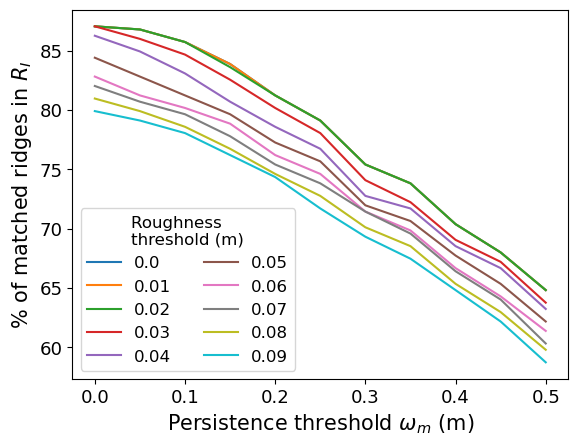

In [7]:
fig, ax = plt.subplots()
sns.lineplot(data = roughness_stats, x = 'persistence', y = 'recall', hue = 'roughness', palette = sns.color_palette("tab10"))
fig.gca().set_xlabel(r'Persistence threshold $\omega_m$ (m)', fontsize = 15)
fig.gca().set_ylabel("% of matched ridges in $R_I$", fontsize = 15)
plt.tick_params(axis='y', labelsize=13.0)
plt.tick_params(axis='x', labelsize=13.0)
plt.legend(title="Roughness \nthreshold (m)", title_fontsize = 12, fontsize = 12, ncol = 2)
plt.savefig('ridge_icesat2_matched_new.png', dpi=1200, bbox_inches='tight') 

In [58]:
roughness_stats['ridge num in OIB (k)'] = roughness_stats['ridge num in OIB']/1000 
roughness_stats['visual range OIB total (k)'] = roughness_stats['visual range OIB total']/1000 

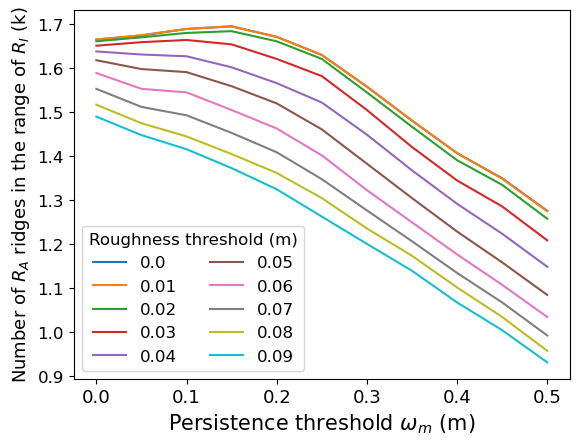

In [8]:
fig, ax = plt.subplots()
sns.lineplot(data = roughness_stats, x = 'persistence', y = 'ridge num in OIB (k)', hue = 'roughness', palette = sns.color_palette("tab10"))
fig.gca().set_ylabel("Number of $R_A$ ridges in the range of $R_I$ (k)", fontsize = 13)
fig.gca().set_xlabel(r'Persistence threshold $\omega_m$ (m)', fontsize = 15)
plt.tick_params(axis='y', labelsize=12.0)
plt.tick_params(axis='x', labelsize=13.0)
plt.legend(title="Roughness threshold (m)", title_fontsize = 12, fontsize = 12, ncol = 2)
plt.savefig('ridge_icesat2_extracted_new.png', dpi=1200, bbox_inches='tight')

In [60]:
roughness_stats.head()

,persistence,length,recall,precision,ridge num in ICESat-2,matched num,ridge num in OIB,visual range matched,visual range OIB total,visual range matched length,visual range ridge length,visual range OIB length,ratio_ridges,roughness,range_ratio_ridges,ridge num in OIB (k),visual range OIB total (k)
0,0.00,0,87.037037,0.283483,378,329,1665,476,1154,8465.752933,11969.168721,71039.072651,0.227027,0,0.412478,1.665,1.154
1,0.05,0,86.772487,0.279570,378,328,1674,475,1141,8077.897731,11969.168721,62825.303380,0.225806,0,0.416301,1.674,1.141
2,0.10,0,85.714286,0.271166,378,324,1689,473,1130,7802.861953,11969.168721,60275.075043,0.223801,0,0.418584,1.689,1.130
3,0.15,0,83.862434,0.254277,378,317,1695,472,1105,7673.285755,11969.168721,60258.088333,0.223009,0,0.427149,1.695,1.105
4,0.20,0,81.216931,0.246559,378,307,1671,469,1070,7527.259326,11969.168721,60055.244608,0.226212,0,0.438318,1.671,1.070


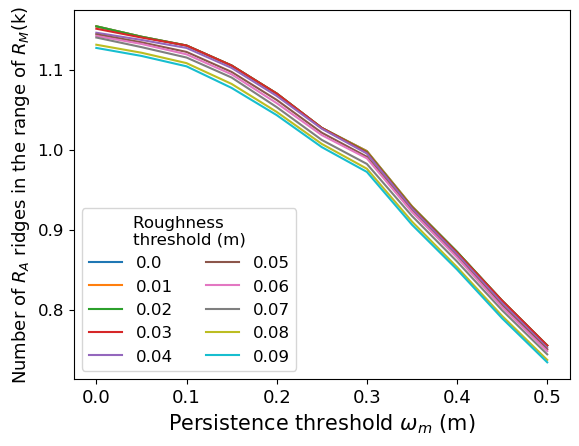

In [10]:
fig, ax = plt.subplots()
sns.lineplot(data = roughness_stats, x = 'persistence', y = 'visual range OIB total (k)', hue = 'roughness', palette = sns.color_palette("tab10"))
fig.gca().set_ylabel("Number of $R_A$ ridges in the range of $R_M$(k)", fontsize = 13)
fig.gca().set_xlabel(r'Persistence threshold $\omega_m$ (m)', fontsize = 15)
plt.tick_params(axis='y', labelsize=12.0)
plt.tick_params(axis='x', labelsize=13.0)
plt.legend(title="Roughness \nthreshold (m)", title_fontsize = 12, fontsize = 12, ncol = 2)
plt.savefig('ridge_visual_extracted_new.png', dpi=1200, bbox_inches='tight')

In [62]:
roughness_stats['range_recall'] = roughness_stats['visual range matched'] / len(visual_checked_ridges) * 100
# roughness_stats['range ridge ratio'] = len(visual_checked_ridges) / roughness_stats['visual range OIB peaks'] * 100

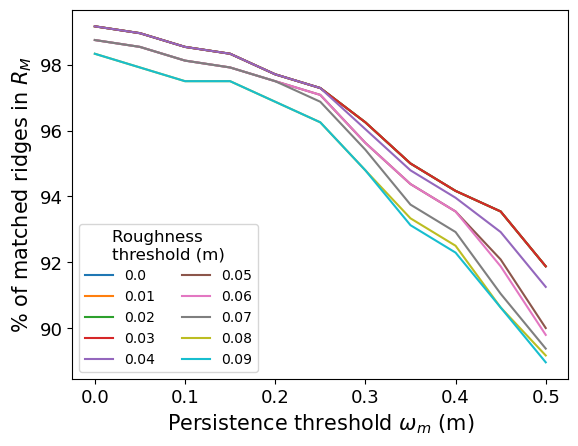

In [12]:
fig, ax = plt.subplots()
sns.lineplot(data = roughness_stats, x = 'persistence', y = 'range_recall', hue = 'roughness', palette = sns.color_palette("tab10"))
fig.gca().set_xlabel(r'Persistence threshold $\omega_m$ (m)', fontsize = 15)
fig.gca().set_ylabel("% of matched ridges in $R_M$", fontsize = 15)
plt.tick_params(axis='y', labelsize=13.0)
plt.tick_params(axis='x', labelsize=13.0)
plt.legend(title="Roughness \nthreshold (m)", title_fontsize = 12, fontsize = 10, ncol = 2)
plt.savefig('ridge_visual_matched_new.png', dpi=1200, bbox_inches='tight')

In [64]:
roughness_stats['length_recall'] = roughness_stats['visual range matched length']/ roughness_stats['visual range ridge length'] * 100

In [65]:
roughness_stats['visual range OIB length (k)'] = roughness_stats['visual range OIB length']/ 1000
roughness_stats['visual range matched length (k)'] = roughness_stats['visual range matched length']/ 1000

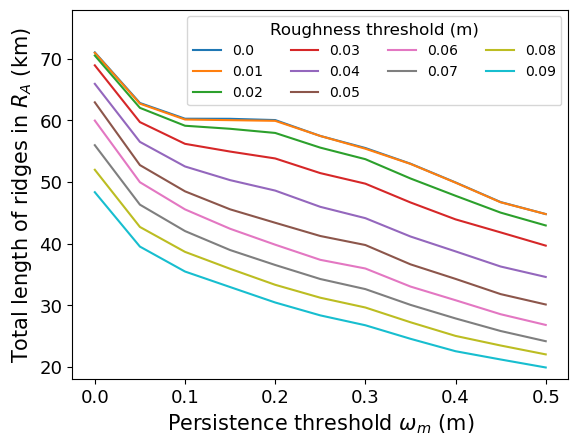

In [18]:
fig, ax = plt.subplots()
sns.lineplot(data = roughness_stats, x = 'persistence', y = 'visual range OIB length (k)', hue = 'roughness', palette = sns.color_palette("tab10"))
fig.gca().set_xlabel(r'Persistence threshold $\omega_m$ (m)', fontsize = 15)
fig.gca().set_ylabel("Total length of ridges in $R_A$ (km)", fontsize = 15)

plt.ylim([18, 78])
plt.tick_params(axis='y', labelsize=13.0)
plt.tick_params(axis='x', labelsize=13.0)
plt.legend(title="Roughness threshold (m)", title_fontsize = 12, fontsize = 10, ncol=4)
plt.savefig('ridge_visual_OIB_length_new.png', dpi=1200, bbox_inches='tight')

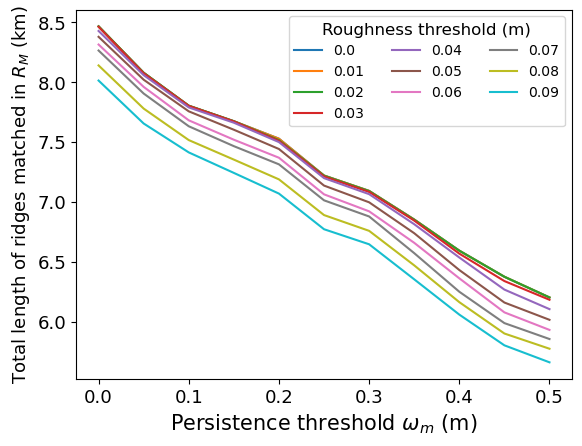

In [23]:
fig, ax = plt.subplots()
sns.lineplot(data = roughness_stats, x = 'persistence', y = 'visual range matched length (k)', hue = 'roughness', palette = sns.color_palette("tab10"))
fig.gca().set_xlabel(r'Persistence threshold $\omega_m$ (m)', fontsize = 15)
fig.gca().set_ylabel("Total length of ridges matched in $R_M$ (km)", fontsize = 13)
plt.tick_params(axis='y', labelsize=13.0)
plt.tick_params(axis='x', labelsize=13.0)
plt.legend(title="Roughness threshold (m)", title_fontsize = 12, fontsize = 10, ncol=3)
plt.savefig('ridge_visual_matched_length_new.png', dpi=1200, bbox_inches='tight')

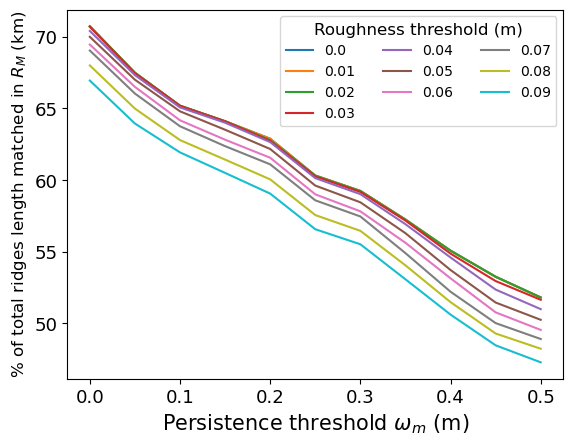

In [22]:
fig, ax = plt.subplots()
sns.lineplot(data = roughness_stats, x = 'persistence', y = 'length_recall', hue = 'roughness', palette = sns.color_palette("tab10"))
fig.gca().set_xlabel(r'Persistence threshold $\omega_m$ (m)', fontsize = 15)
fig.gca().set_ylabel("% of total ridges length matched in $R_M$ (km)", fontsize = 12)
plt.tick_params(axis='y', labelsize=13.0)
plt.tick_params(axis='x', labelsize=13.0)
plt.legend(title="Roughness threshold (m)", title_fontsize = 12, fontsize = 10, ncol=3)
plt.savefig('ridge_visual_matched_length_percentage_new.png', dpi=1200, bbox_inches='tight')

In [21]:
roughness_stats.loc[(roughness_stats['range_recall'] >= 95) & (roughness_stats['recall'] >= 70) ].sort_values('visual range OIB length').head(20)

,Unnamed: 0,persistence,length,roughness,recall,precision,ridge num in ICESat-2,matched num,ridge num in OIB,visual range matched,visual range OIB total,visual range matched length,visual range ridge length,visual range OIB length,ridge num in OIB (k),visual range OIB total (k),range_recall,length_recall,visual range OIB length (k),visual range matched length (k)
93,5,0.25,0,0.09,71.693122,0.274743,378,271,1263,462,1003,6771.254761,11969.168721,28347.122167,1.263,1.003,96.250000,56.572473,28.347122,6.771255
92,4,0.20,0,0.09,74.338624,0.278491,378,281,1325,465,1043,7068.808597,11969.168721,30439.679261,1.325,1.043,96.875000,59.058476,30.439679,7.068809
82,5,0.25,0,0.08,72.751323,0.274330,378,275,1305,462,1007,6889.476064,11969.168721,31215.989616,1.305,1.007,96.250000,57.560188,31.215990,6.889476
72,6,0.30,0,0.07,71.428571,0.273297,378,270,1277,458,982,6877.792778,11969.168721,32613.419105,1.277,0.982,95.416667,57.462577,32.613419,6.877793
91,3,0.15,0,0.09,76.190476,0.280408,378,288,1373,468,1077,7241.586626,11969.168721,32947.983771,1.373,1.077,97.500000,60.502001,32.947984,7.241587
81,4,0.20,0,0.08,74.603175,0.276799,378,282,1362,465,1047,7187.638046,11969.168721,33311.816235,1.362,1.047,96.875000,60.051272,33.311816,7.187638
71,5,0.25,0,0.07,73.809524,0.269288,378,279,1348,465,1012,7012.616177,11969.168721,34252.540112,1.348,1.012,96.875000,58.588999,34.252540,7.012616
90,2,0.10,0,0.09,78.042328,0.289548,378,295,1416,468,1104,7412.792461,11969.168721,35465.443349,1.416,1.104,97.500000,61.932392,35.465443,7.412792
80,3,0.15,0,0.08,76.719577,0.281139,378,290,1405,468,1082,7352.656253,11969.168721,35912.730809,1.405,1.082,97.500000,61.429966,35.912731,7.352656
61,6,0.30,0,0.06,71.428571,0.264550,378,270,1323,459,989,6920.707912,11969.168721,35958.507533,1.323,0.989,95.625000,57.821124,35.958508,6.920708


In [107]:
roughness_stats.to_csv('ridge_stats_v2.csv')

In [180]:
roughness_stats.loc[(roughness_stats['visual range OIB length'] < 11969.168721 * 3)  ].sort_values('length_recall', ascending = False).head(10)

,persistence,length,recall,precision,ridge num in ICESat-2,matched num,ridge num in OIB,visual range matched,visual range OIB total,visual range matched length,visual range ridge length,visual range OIB length,roughness,ratio_ridges,ridge num in OIB (k),visual range OIB total (k),range_recall,length_recall
31,0.15,0,76.190476,0.293620,378,288,1301,465,1078,7216.669300,11969.168721,33789.535232,0.08,0.290546,1.301,1.078,96.875000,60.293822
38,0.20,0,74.867725,0.281853,378,283,1295,462,1050,7151.501619,11969.168721,34437.796781,0.07,0.291892,1.295,1.050,96.250000,59.749359
39,0.20,0,74.074074,0.286171,378,280,1251,461,1043,7042.580707,11969.168721,31334.413784,0.08,0.302158,1.251,1.043,96.041667,58.839347
45,0.25,0,73.809524,0.273636,378,279,1301,464,1016,6922.705227,11969.168721,35571.937552,0.06,0.290546,1.301,1.016,96.666667,57.837811
46,0.25,0,73.280423,0.283200,378,277,1250,459,1009,6846.474111,11969.168721,32160.472984,0.07,0.302400,1.250,1.009,95.625000,57.200916
53,0.30,0,71.164021,0.282411,378,269,1211,457,987,6786.835675,11969.168721,34211.769818,0.06,0.312139,1.211,0.987,95.208333,56.702649
47,0.25,0,71.957672,0.283594,378,272,1213,458,1003,6746.205884,11969.168721,29418.219702,0.08,0.311624,1.213,1.003,95.416667,56.363195
54,0.30,0,71.164021,0.291702,378,269,1169,452,979,6721.393318,11969.168721,30593.692040,0.07,0.323353,1.169,0.979,94.166667,56.155891
55,0.30,0,69.576720,0.291005,378,263,1134,451,972,6620.063644,11969.168721,27674.740421,0.08,0.333333,1.134,0.972,93.958333,55.309302
60,0.35,0,69.576720,0.275174,378,263,1152,450,923,6586.933693,11969.168721,34776.170039,0.05,0.328125,1.152,0.923,93.750000,55.032508


In [162]:
roughness_stats.loc[(roughness_stats['recall'] >= 75)].sort_values('ridge num in OIB')

,persistence,length,recall,precision,ridge num in ICESat-2,matched num,ridge num in OIB,visual range matched,visual range OIB total,visual range matched length,visual range ridge length,visual range OIB length,roughness,ratio_ridges,ridge num in OIB (k),visual range OIB total (k),range_recall,length_recall
31,0.15,0,76.190476,0.293620,378,288,1301,465,1078,7216.669300,11969.168721,33789.535232,0.08,0.290546,1.301,1.078,96.875000,60.293822
30,0.15,0,77.513228,0.290828,378,293,1341,467,1085,7319.324859,11969.168721,36816.509531,0.07,0.281879,1.341,1.085,97.291667,61.151489
37,0.20,0,75.396825,0.274146,378,285,1346,466,1054,7228.838990,11969.168721,37984.943098,0.06,0.280832,1.346,1.054,97.083333,60.395497
23,0.10,0,78.306878,0.304154,378,296,1348,465,1106,7384.310124,11969.168721,36400.353972,0.08,0.280415,1.348,1.106,96.875000,61.694428
29,0.15,0,78.306878,0.283862,378,296,1388,470,1091,7389.700428,11969.168721,40681.094527,0.06,0.272334,1.388,1.091,97.916667,61.739462
22,0.10,0,79.629630,0.301439,378,301,1390,467,1111,7482.691306,11969.168721,39637.654554,0.07,0.271942,1.390,1.111,97.291667,62.516383
36,0.20,0,76.190476,0.267960,378,288,1392,466,1062,7296.301430,11969.168721,41456.691590,0.05,0.271552,1.392,1.062,97.083333,60.959133
15,0.05,0,79.629630,0.297857,378,301,1400,468,1120,7653.387878,11969.168721,40394.398044,0.08,0.270000,1.400,1.120,97.500000,63.942518
49,0.30,0,75.132275,0.255682,378,284,1408,460,997,6965.709762,11969.168721,52714.735656,0.02,0.268466,1.408,0.997,95.833333,58.197106
43,0.25,0,76.190476,0.261854,378,288,1413,465,1026,7044.244435,11969.168721,43873.424582,0.04,0.267516,1.413,1.026,96.875000,58.853247


In [82]:
roughness_stats.sort_values('recall', ascending = False)

,persistence,length,recall,precision,ridge num in ICESat-2,matched num,ridge num in OIB,visual range matched,visual range OIB total,visual range matched length,visual range ridge length,visual range OIB length,roughness,ratio_ridges,ridge num in OIB (k),visual range OIB total (k),range_recall
0,0.00,0,87.037037,0.295396,378,329,1564,476,1152,8406.739064,11969.168721,69799.082123,0,0.241688,1.564,1.152,99.166667
0,0.00,0,87.037037,0.295585,378,329,1563,476,1152,8406.739064,11969.168721,69713.073180,0.01,0.241843,1.563,1.152,99.166667
1,0.00,0,87.037037,0.295702,378,329,1559,476,1151,8406.387324,11969.168721,69179.282870,0.02,0.242463,1.559,1.151,99.166667
2,0.00,0,87.037037,0.297542,378,329,1546,476,1149,8392.113586,11969.168721,66902.418755,0.03,0.244502,1.546,1.149,99.166667
1,0.05,0,86.772487,0.291195,378,328,1590,475,1141,7991.387896,11969.168721,61669.454245,0,0.237736,1.590,1.141,98.958333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,0.45,0,62.169312,0.279793,378,235,965,429,761,5750.277641,11969.168721,22033.062162,0.08,0.391710,0.965,0.761,89.375000
84,0.50,0,60.846561,0.266802,378,230,982,428,697,5873.481877,11969.168721,28674.091518,0.05,0.384929,0.982,0.697,89.166667
85,0.50,0,60.582011,0.277070,378,229,942,426,695,5768.866281,11969.168721,25279.017241,0.06,0.401274,0.942,0.695,88.750000
86,0.50,0,59.523810,0.283186,378,225,904,423,689,5712.963614,11969.168721,22723.374882,0.07,0.418142,0.904,0.689,88.125000


/var/folders/kf/p07s6zg94d17kb3jf1_j08gm0000gn/T/ipykernel_58515/3852601514.py:2: UserWarning: The palette list has more values (10) than needed (9), which may not be intended.
  sns.lineplot(data = roughness_stats, x = 'persistence', y = 'visual range OIB total (k)', hue = 'roughness', palette = sns.color_palette("tab10"))


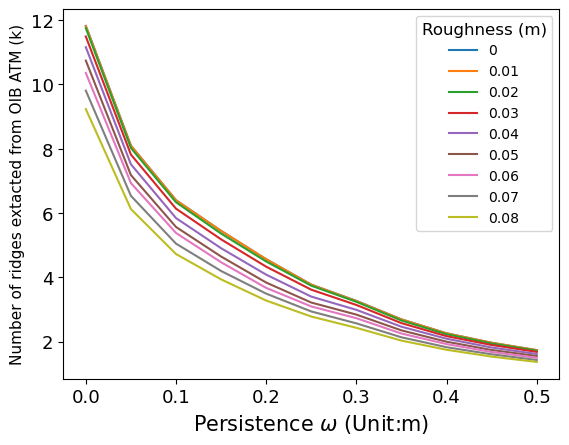

In [188]:
fig, ax = plt.subplots()
sns.lineplot(data = roughness_stats, x = 'persistence', y = 'visual range OIB total (k)', hue = 'roughness', palette = sns.color_palette("tab10"))
fig.gca().set_xlabel(r'Persistence $\omega$ (Unit:m)', fontsize = 15)
fig.gca().set_ylabel("Number of ridges extacted from OIB ATM (k)", fontsize = 11)
plt.tick_params(axis='y', labelsize=13.0)
plt.tick_params(axis='x', labelsize=13.0)
plt.legend(title="Roughness threshold (m)", title_fontsize = 12, fontsize = 10)
# plt.savefig('ridge_visual_extracted.png', dpi=1200, bbox_inches='tight')

/var/folders/kf/p07s6zg94d17kb3jf1_j08gm0000gn/T/ipykernel_58515/3346873118.py:1: UserWarning: The palette list has more values (10) than needed (9), which may not be intended.
  sns.lineplot(data = roughness_stats, x = 'persistence', y = 'range ridge ratio', hue = 'roughness', palette = sns.color_palette("tab10"))


<Axes: xlabel='persistence', ylabel='range ridge ratio'>

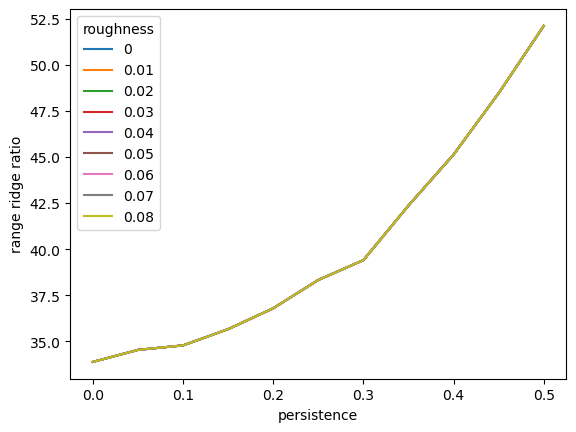

In [ ]:
sns.lineplot(data = roughness_stats, x = 'persistence', y = 'range ridge ratio', hue = 'roughness', palette = sns.color_palette("tab10"))

In [ ]:
sns.lineplot(data = roughness_stats, x = 'persistence', y = 'range ridge ratio', hue = 'roughness', palette = sns.color_palette("tab10"))

In [44]:
file_name = generate_ridge_line_file_name("0.5", "20", 0, False)
ridges = read_ridge_lines_wkt(file_name, False)
recall, precision, icebridge_peaks = evaluate_ridge_results(ridges, icesat2_ridges, icesat2_path)


TypeError: generate_ridge_line_file_name() missing 1 required positional argument: 'part_name'

In [21]:
icebridge_peaks['distance'] = icebridge_peaks.apply(project_distance_gdf,icesat2_path = icesat2_path, axis = 1)

NameError: name 'icebridge_peaks' is not defined

In [274]:
icebridge_peaks['elevation']  = icebridge_peaks['elevation'] - 0.31

In [27]:

# df = pd.read_csv("/Users/robo/Downloads/profile_dataframe.csv")
df_icebridge = df.loc[df['dataset'] == 'OIB ATM-TIN']
df_icesat2 = df.loc[df['dataset'] == 'ICESat-2 UMD-RDA']

In [28]:
# clipped_icesat2_ridges
icesat2_ridges_distance = clipped_icesat2_ridges['distance']
icesat2_elevation = np.interp(icesat2_ridges_distance, df_icebridge['distance'], df_icebridge['z'])

In [29]:
clipped_icesat2_ridges['interpolated_elevation'] = icesat2_elevation

/Users/robo/miniconda3/envs/jupyter_nb/lib/python3.10/site-packages/geopandas/geodataframe.py:1538: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  super().__setitem__(key, value)


In [146]:
acceptable = 25/ len(clipped_icesat2_ridges )
print(acceptable)

0.06613756613756613


In [30]:
clipped_icesat2_ridges.loc[(clipped_icesat2_ridges.index >= 0) & (clipped_icesat2_ridges.index <182), 'interpolated_elevation'] = clipped_icesat2_ridges.loc[(clipped_icesat2_ridges.index >= 0) & (clipped_icesat2_ridges.index <182)].interpolated_elevation + 0.31

In [31]:
clipped_icesat2_ridges.loc[(clipped_icesat2_ridges.index >= 182) & (clipped_icesat2_ridges.index <275), 'interpolated_elevation'] = clipped_icesat2_ridges.loc[(clipped_icesat2_ridges.index >= 182) & (clipped_icesat2_ridges.index < 275)].interpolated_elevation + 0.3

In [32]:
clipped_icesat2_ridges.loc[(clipped_icesat2_ridges.index >= 275), 'interpolated_elevation'] = clipped_icesat2_ridges.loc[(clipped_icesat2_ridges.index >= 275)].interpolated_elevation + 0.22

In [216]:
clipped_icesat2_ridges.loc[clipped_icesat2_ridges.index == 303]

,elevation,geometry,distance,interpolated_elevation
303,0.426631,POINT (194339.978 -480273.205),54186.415896,0.341945


In [34]:
lower_peaks = clipped_icesat2_ridges.loc[(clipped_icesat2_ridges.interpolated_elevation < 0)]
print(lower_peaks.index)

Index([392, 378, 376, 375, 372, 352, 344, 343, 338, 332, 325, 320, 319, 317,
       313, 299, 296, 290, 283, 279, 278, 277, 276, 274, 273, 271, 266, 265,
       264, 263, 261, 257, 255, 253, 252, 251, 250, 248, 240, 235, 229, 228,
       204, 202, 193, 188, 185, 183, 182, 179, 178, 177, 176, 175, 174, 173,
       172, 168, 167, 152, 128, 120, 115, 114, 108,  87,  74,  62,  58,  55,
        50,  42,  34],
      dtype='int64')


In [35]:
FN = [25, 49, 50, 54, 62, 70, 75, 82, 87, 91, 102, 105, 108, 112, 113, 115, 116, 120, 131, 136, 137, 144, 148, 157, 163, 167, 168, 171, 172, 175, 177, 178, 179, 180, 181, 182, 183, 184, 185, 191, 195, 196, 202, 203, 204, 205, 211, 216, 218, 219, 229, 233, 235, 242, 244, 247, 250, 253, 254, 255, 257, 258, 261, 262, 263, 265, 266, 267, 269, 273, 274, 275, 276, 278, 279, 288, 290, 291, 296, 299, 303, 310, 313, 319, 320, 330, 344, 346, 347, 351, 352, 354, 355, 356, 357, 358, 359, 361, 362, 363, 376, 378, 380, 381, 389, 390, 393]
FN_peaks = clipped_icesat2_ridges.loc[FN]

In [223]:
FN_peaks.sort_values('interpolated_elevation', ascending = False)

,elevation,geometry,distance,interpolated_elevation
25,0.432624,POINT (196630.964 -429306.258),3159.225440,0.676460
346,0.495045,POINT (193863.776 -490606.029),64530.434247,0.648717
357,2.518416,POINT (193767.541 -492687.507),66614.258930,0.597460
389,0.592729,POINT (193646.322 -495321.864),69251.425626,0.580606
361,1.126054,POINT (193760.095 -492847.972),66774.899775,0.564017
...,...,...,...,...
167,0.290611,POINT (195840.344 -447355.692),21234.031715,-0.252060
173,0.395406,POINT (195815.821 -447902.581),21781.518939,-0.291243
296,0.353764,POINT (194352.376 -480002.134),53915.059274,-0.355477
179,0.284241,POINT (195735.407 -449732.653),23613.367290,-0.383873


In [38]:
rest = (set(FN) - set(lower_peaks.index))

In [40]:
lower_FN = set(FN) - set(rest)
lower_FN = list(lower_FN)
lower_FN.sort()
print(lower_FN)
print(len(lower_FN))

[50, 62, 87, 108, 115, 120, 167, 168, 172, 175, 177, 178, 179, 182, 183, 185, 202, 204, 229, 235, 250, 253, 255, 257, 261, 263, 265, 266, 273, 274, 276, 278, 279, 290, 296, 299, 313, 319, 320, 344, 352, 376, 378]
43


In [263]:
sns.lineplot(data = evaluation_stats, x = 'persistence', y = 'recall', hue = 'length', palette = sns.color_palette("tab10"))
plt.axhline(y= 0.75, c = 'r', linestyle = '--' ) 

,elevation,geometry,distance,dataset
0,0.330508,POINT (196765.531 -426196.757),46.792864,ICESat-2 ridges
1,0.442424,POINT (196763.299 -426247.004),97.090314,ICESat-2 ridges
2,0.420149,POINT (196760.415 -426316.620),166.765590,ICESat-2 ridges
3,1.686312,POINT (196745.619 -426650.784),501.257855,ICESat-2 ridges
4,1.932498,POINT (196744.893 -426667.399),517.889128,ICESat-2 ridges
5,0.743990,POINT (196742.562 -426723.449),573.988054,ICESat-2 ridges
6,0.703856,POINT (196735.502 -426901.626),752.306364,ICESat-2 ridges
7,0.965096,POINT (196734.620 -426920.873),771.572923,ICESat-2 ridges
8,0.572150,POINT (196729.354 -427037.769),888.588358,ICESat-2 ridges
9,0.707557,POINT (196714.066 -427396.862),1248.009223,ICESat-2 ridges


In [91]:
icebridge_peaks = oib_intersections.sort_values(by=['distance'])
icebridge_peaks[0:10]

,elevation,geometry,distance
1062,0.117136,POINT (196765.722 -426192.629),42.660457
1061,0.149875,POINT (196763.394 -426244.769),94.853144
1060,0.059908,POINT (196763.303 -426246.909),96.995246
1059,0.439099,POINT (196760.672 -426310.308),160.448748
1058,0.327324,POINT (196760.575 -426312.678),162.820067
1057,1.065321,POINT (196745.785 -426646.859),497.329709
1056,0.963426,POINT (196745.240 -426659.291),509.773451
1055,1.418188,POINT (196745.203 -426660.339),510.822431
1054,1.272364,POINT (196745.170 -426661.007),511.491036
1053,0.771884,POINT (196742.686 -426720.266),570.802373


In [69]:
icesat2_ridges = clipped_icesat2_ridges.sort_values(by=['distance'])

In [92]:
icesat2_ridges.head()

,elevation,geometry,distance,dataset
0,0.330508,POINT (196765.531 -426196.757),46.792864,ICESat-2 UMD-RDA ridges
1,0.442424,POINT (196763.299 -426247.004),97.090314,ICESat-2 UMD-RDA ridges
2,0.420149,POINT (196760.415 -426316.620),166.765590,ICESat-2 UMD-RDA ridges
3,1.686312,POINT (196745.619 -426650.784),501.257855,ICESat-2 UMD-RDA ridges
4,1.932498,POINT (196744.893 -426667.399),517.889128,ICESat-2 UMD-RDA ridges


In [77]:
left_end = 1000
right_end = 2000

In [93]:
icesat2_ridges['dataset'] = 'ICESat-2 UMD-RDA ridges'
icebridge_peaks['dataset'] = 'OIB ATM-TIN ridges'
ridges_plot = pd.concat([icebridge_peaks, icesat2_ridges], ignore_index=True)

In [94]:
ridges_plot

,elevation,geometry,distance,dataset
0,0.117136,POINT (196765.722 -426192.629),42.660457,OIB ATM-TIN ridges
1,0.149875,POINT (196763.394 -426244.769),94.853144,OIB ATM-TIN ridges
2,0.059908,POINT (196763.303 -426246.909),96.995246,OIB ATM-TIN ridges
3,0.439099,POINT (196760.672 -426310.308),160.448748,OIB ATM-TIN ridges
4,0.327324,POINT (196760.575 -426312.678),162.820067,OIB ATM-TIN ridges
...,...,...,...,...
1436,0.550136,POINT (193632.419 -495619.971),69549.858808,ICESat-2 UMD-RDA ridges
1437,1.151035,POINT (193625.877 -495772.964),69702.992243,ICESat-2 UMD-RDA ridges
1438,0.600774,POINT (193610.370 -496092.891),70023.307383,ICESat-2 UMD-RDA ridges
1439,0.613020,POINT (193607.242 -496163.695),70094.179859,ICESat-2 UMD-RDA ridges


In [63]:
# clipped_icesat2_ridges.loc[(clipped_icesat2_ridges.index >= 275), 'interpolated_elevation'] = clipped_icesat2_ridges.loc[(clipped_icesat2_ridges.index >= 275)].interpolated_elevation + 0.22
df.loc[df['dataset'] == 'OIB ATM', 'dataset'] = 'OIB ATM-TIN'
df.loc[df['dataset'] == 'ICESat-2', 'dataset'] = 'ICESat-2 UMD-RDA'

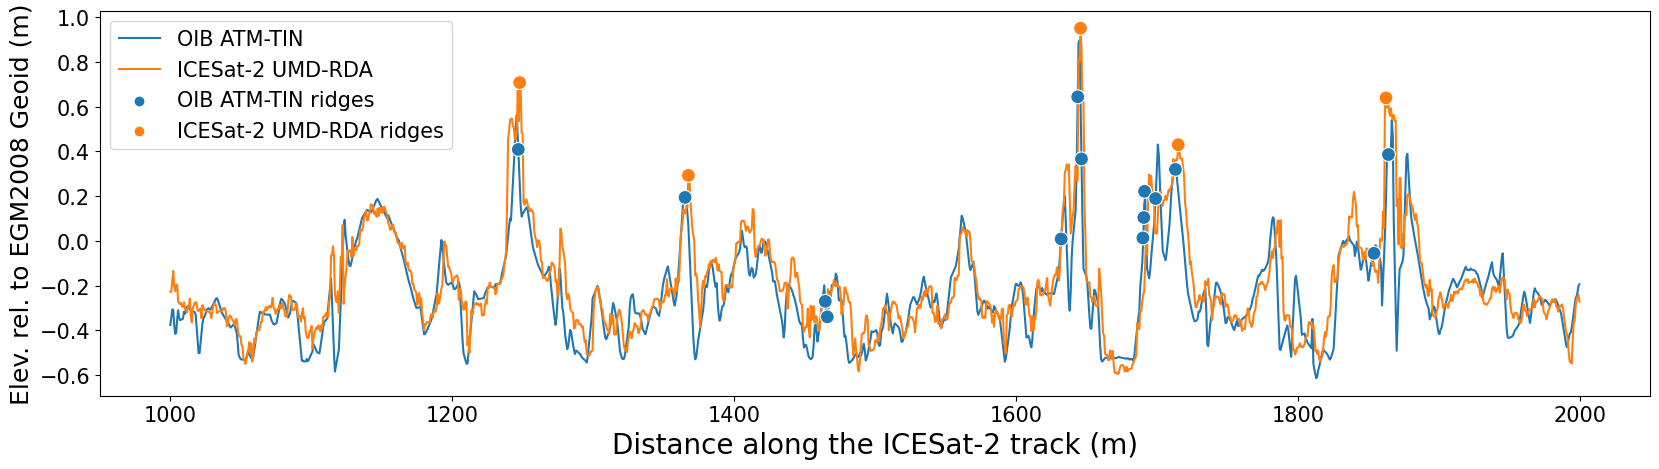

In [95]:

plt.figure(figsize=(20,5))

ax1 = sns.lineplot(data = df.loc[(df['distance'] >= left_end) & (df['distance'] < right_end) ], hue = 'dataset', x = 'distance', y = 'z', zorder = 1)
sns.scatterplot(data = ridges_plot.loc[(ridges_plot['distance'] >= left_end) & (ridges_plot['distance'] < right_end)  ], x = 'distance', y = 'elevation', s= 100, 
                hue = 'dataset')

plt.legend(prop={'size': 15})
plt.tick_params(axis='y', labelsize=15.0)
plt.tick_params(axis='x', labelsize=15.0)
plt.xlabel("Distance along the ICESat-2 track (m)", fontsize=20)
plt.ylabel("Elev. rel. to EGM2008 Geoid (m)", fontsize = 18)
plt.savefig('profile_1_to_2km_p025_r008.png', dpi=1200, bbox_inches='tight')

# Compare critical points to peaks from ICESat2

In [515]:
critical_points = pd.read_csv("/Users/robo/data/leg6_processed/leg6_projected_ridges_region_part1_as_30.000000_0.6_a50_simplified_critical_points.txt")
possible_peaks = critical_points.loc[critical_points['type'] != 'min']
ply_coord = [Point(x, y) for x, y in zip(possible_peaks.x, possible_peaks.y)]
possible_peaks = gpd.GeoDataFrame(possible_peaks, geometry=ply_coord, crs ="EPSG:3411")
nearby_peaks = gpd.clip(possible_peaks, icesat2_path.buffer(5))
len(nearby_peaks)

In [344]:
ridges_crit_distance_icebridge = []
for nearby_peak in nearby_peaks['geometry']:
    ridges_crit_distance_icebridge.append(icesat2_path.project(nearby_peak))
                                          
ridges_crit_distance_icebridge.sort()
print(ridges_crit_distance_icebridge[0:10])
print(len(ridges_crit_distance_icebridge))    

In [511]:
# ridge from critical points extracted from icebridge
icebridge_ridges_crit_for_plot = [x for x in ridges_crit_distance_icebridge if x < right_end and x >= left_end ]
icebridge_crit_elevation =  np.interp(icebridge_ridges_crit_for_plot, df_icebridge['distance'], df_icebridge['z'])
ridges_crit_icebridge = pd.DataFrame({'distance':icebridge_ridges_crit_for_plot, 'z':icebridge_crit_elevation})
ridges_crit_icebridge['dataset'] = 'OIB ATM ridges'
ridges_plot2 = pd.concat([ridges_crit_icebridge, ridges_icesat2], ignore_index=True)

138

Text(0, 0.5, 'Elevation (m)')

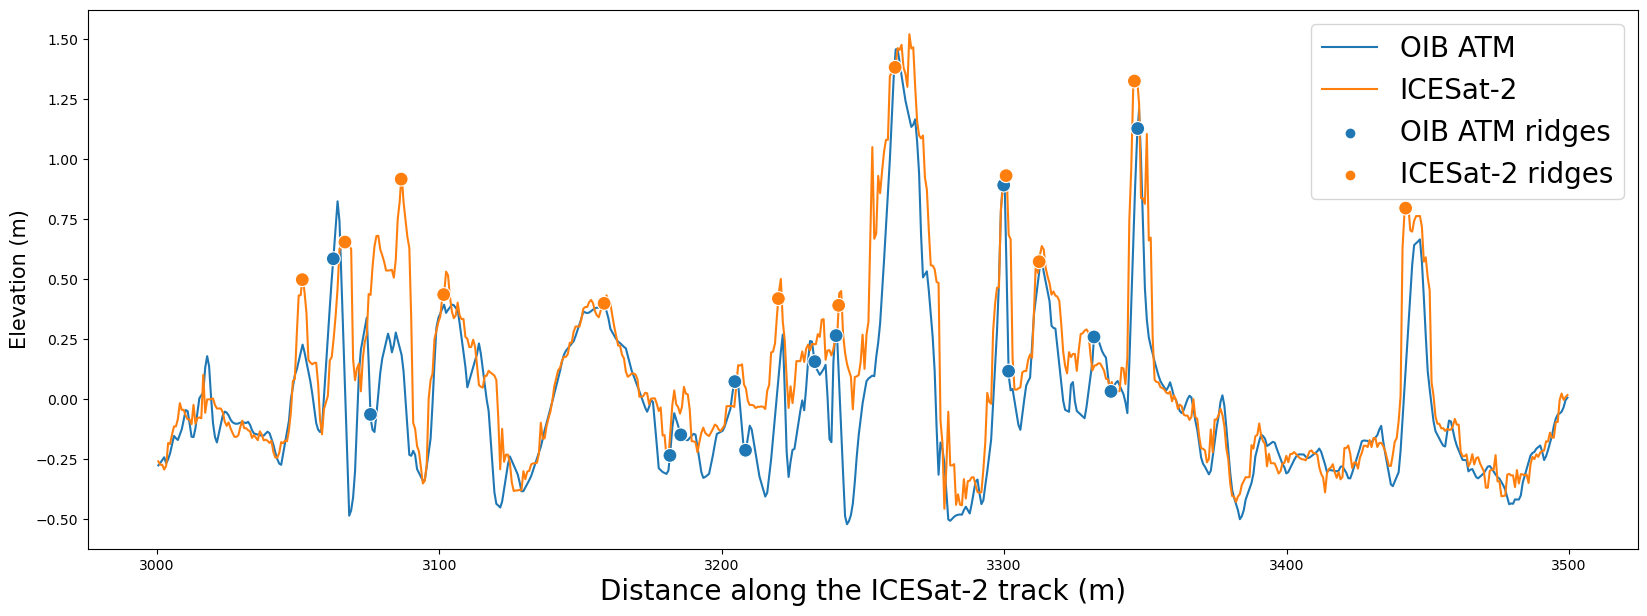

In [387]:
plt.figure(figsize=(20,7))

ax1 = sns.lineplot(data = df.loc[(df['distance'] >= left_end) & (df['distance'] < right_end) ], hue = 'dataset', x = 'distance', y = 'z', zorder = 1)
# ax2 = plt.scatter(icesat2_ridges_for_plot, icesat2_elevation, marker='^', linewidths=2, color='r', zorder=3)
sns.scatterplot(data = ridges_plot2, x = 'distance', y='z',  s=100, hue = 'dataset')
plt.legend(prop={'size': 20})
plt.xlabel("Distance along the ICESat-2 track (m)", fontsize=20)
plt.ylabel("Elevation (m)", fontsize = 15)

# Ridge orientation

In [657]:
def read_ridge_lines_wkt_elevation(file_name):
    # ridges_elev = []
    rid = []
    left_x = []
    left_y = []
    left_ele = []
    right_x = []
    right_y = []
    right_ele = []
    top_x = []
    top_y = []
    top_ele = []
    bottom_x = []
    bottom_y = []
    bottom_ele = []
    features = []
    # ridges = gpd.GeoDataFrame(columns=['feature', 'ridge id'] ,crs = "EPSG:3411", geometry='feature')
    with io.open(file_name, mode="r", encoding="utf-8") as f:
        next(f)
        for line in f:
            parts = line.split('\"')
            info = parts[2].split(',')
            elev1 =  float(info[1])
            elev2 = float(info[2])
            ridge_id = int(info[3])
            wkt = parts[1]
            # wkt = parts[1].replace(', )', ')') # error in the early version of writer in C++ code.
            geometry = shapely.wkt.loads(wkt)
            point_1 = geometry.coords[0]
            point_2 = geometry.coords[1]
            if point_1[0] < point_2[0]:
                left_x.append(point_1[0])
                left_y.append(point_1[1])
                left_ele.append(elev1)
                right_x.append(point_2[0])
                right_y.append(point_2[1])
                right_ele.append(elev2)
            else:
                left_x.append(point_2[0])
                left_y.append(point_2[1])
                left_ele.append(elev2)
                right_x.append(point_1[0])
                right_y.append(point_1[1])
                right_ele.append(elev1)
                
            if point_1[1] < point_2[1]:
                bottom_x.append(point_1[0])
                bottom_y.append(point_1[1])
                bottom_ele.append(elev1)
                top_x.append(point_2[0])
                top_y.append(point_2[1])
                top_ele.append(elev2)
            else:
                bottom_x.append(point_2[0])
                bottom_y.append(point_2[1])
                bottom_ele.append(elev2)
                top_x.append(point_1[0])
                top_y.append(point_1[1])
                top_ele.append(elev1)               
            # ridges_elev.append(top)
            features.append(geometry)
            rid.append(ridge_id)

    ridges = gpd.GeoDataFrame(data= { "left_x":left_x, "left_y":left_y,"left_ele":left_ele, "right_x":right_x, "right_y":right_y, "right_ele":right_ele,"bottom_x": bottom_x, 
                                 "bottom_y":bottom_y, "bottom_ele":bottom_ele, "top_x":top_x, "top_y":top_y, "top_ele":top_ele, "ridge id":rid, "feature":features}, geometry = "feature")
                     
    return ridges

In [658]:
part1_name = generate_ridge_line_file_name(persistence, length, roughness, True, "part1_v2")
ridge_part1 = read_ridge_lines_wkt_elevation(part1_name)
part2_name = generate_ridge_line_file_name(persistence, length, roughness, True, "part2_v2")
ridge_part2 = read_ridge_lines_wkt_elevation(part2_name)
ridge_part2['ridge id'] = ridge_part2['ridge id'] + ridge_part1['ridge id'].max() + 1
part3_name = generate_ridge_line_file_name(persistence, length, roughness, True, "part3_v2")
ridge_part3 = read_ridge_lines_wkt_elevation(part3_name)
ridge_part3['ridge id'] = ridge_part3['ridge id'] + ridge_part2['ridge id'].max() + 1
ridges = pd.concat([ridge_part1, ridge_part2, ridge_part3], ignore_index=True)

In [547]:
def min_coord(row, index):
    if row.feature.coords[0]
    return min(row.feature.coords[0][index], row.feature.coords[1][index])

In [ ]:
def max_coord(row, index):
    return max(row.feature.coords[0][index], row.feature.coords[1][index])

In [567]:
def get_endpoints(linestring):
    if isinstance(linestring, LineString):
        if linestring.coords[0][0] < linestring.coords[-1][0]:
            return linestring.coords[0], linestring.coords[-1]
        else:
            return linestring.coords[-1], linestring.coords[0]
    else:
        return None, None  # or some form of placeholder for non-LineStrings


In [584]:
def get_endpoints_y(linestring):
    if isinstance(linestring, LineString):
        if linestring.coords[0][1] < linestring.coords[-1][1]:
            return linestring.coords[0], linestring.coords[-1]
        else:
            return linestring.coords[-1], linestring.coords[0]
    else:
        return None, None  # or some form of placeholder for non-LineStrings

In [661]:
ridges['length'] = ridges.geometry.length

In [663]:
grouped_ridges = ridges.groupby('ridge id')

In [664]:
y_left = grouped_ridges.apply(lambda x: x.loc[x.left_x.idxmin(), 'left_y'])
y_right = grouped_ridges.apply(lambda x: x.loc[x.right_x.idxmax(), 'right_y'])
x_right = grouped_ridges.apply(lambda x: x.right_x.max())
x_left = grouped_ridges.apply(lambda x: x.left_x.min())
ele_left = grouped_ridges.apply(lambda x: x.loc[x.left_x.idxmin(), 'left_ele'])
ele_right = grouped_ridges.apply(lambda x: x.loc[x.right_x.idxmax(), 'right_ele'])
sum_length = grouped_ridges.apply(lambda x: x.length.sum())

In [665]:
x_bottom = grouped_ridges.apply(lambda x: x.loc[x.bottom_y.idxmin(), 'bottom_x'])
x_top = grouped_ridges.apply(lambda x: x.loc[x.top_y.idxmax(), 'top_x'])
y_top = grouped_ridges.apply(lambda x: x.top_y.max())
y_bottom = grouped_ridges.apply(lambda x: x.bottom_y.min())
ele_bottom = grouped_ridges.apply(lambda x: x.loc[x.bottom_y.idxmin(), 'bottom_ele'])
ele_top = grouped_ridges.apply(lambda x: x.loc[x.top_y.idxmax(), 'top_ele'])

In [666]:
bounds = pd.DataFrame({'left_x': x_left,  "left_y": y_left, 'left_ele':ele_left, 'right_x': x_right,
                       "right_y": y_right, "right_ele":ele_right, "top_x": x_top, "top_y": y_top, 
                       "top_ele": ele_top, "bottom_x": x_bottom, "bottom_y": y_bottom, "bottom_ele":ele_bottom, "total_length":sum_length })

In [667]:
ridge_details = bounds.join(peak_stats_df)

# ridge size distribution

In [518]:
peaks = []
peaks_stats = []
length = "0"
roughness = "0.08"
persistence = "0.15"
part1_peak_name = generate_ridge_peak_file_name(persistence, length, roughness, True, "part1_v2")
peaks, peaks_stats  = read_ridge_peak_points(part1_peak_name, peaks, peaks_stats)
part2_peak_name = generate_ridge_peak_file_name(persistence, length, roughness, True, "part2_v2")
peaks, peaks_stats  = read_ridge_peak_points(part2_peak_name, peaks, peaks_stats)
part3_peak_name = generate_ridge_peak_file_name(persistence, length, roughness, True, "part3_v2")
peaks, peaks_stats  = read_ridge_peak_points(part3_peak_name, peaks, peaks_stats)
peak_stats_df = pd.DataFrame(peaks_stats, columns=['relative elevation', 'absolute elevation', 'length'])
peak_stats_gdf = gpd.GeoDataFrame(peak_stats_df, crs = 'epsg:3411', geometry = peaks)
# clipped_oib_peaks = peak_stats_gdf.clip(ridge_range_gdf)
# evaluation_roughness_stats.loc[len(evaluation_roughness_stats)]=[persistence, length, roughness] + stats + visual_res #+ [len(clipped_oib_peaks)]

<Figure size 1000x1000 with 0 Axes>

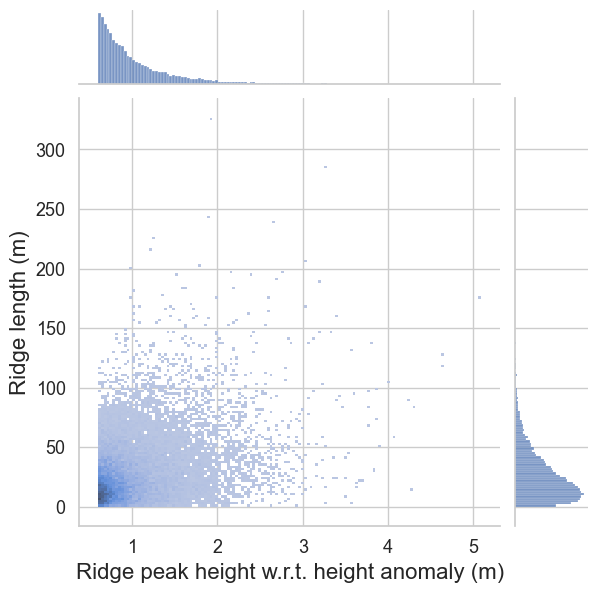

In [677]:
ridge_details.head()
plt.figure(figsize=(10,10))
# sns.jointplot(data=peak_stats_gdf.loc[(peak_stats_gdf["relative elevation"] < 3) & (peak_stats_gdf["length"]> 100)], x="relative elevation", y="length", kind="hist")
sns.jointplot(data=ridge_details, x="relative elevation", y="total_length", kind="hist")
plt.ylabel("Ridge length (m)", fontsize = 16)
plt.xlabel(r"Ridge peak height w.r.t. height anomaly (m)", fontsize = 16)
plt.tick_params(axis='y', labelsize=13.0)
plt.tick_params(axis='x', labelsize=13.0)

mean: 1.01 m
range: 0.60 m, 5.09 m
Total count: 22029
mode (unit:m): 0.62 m


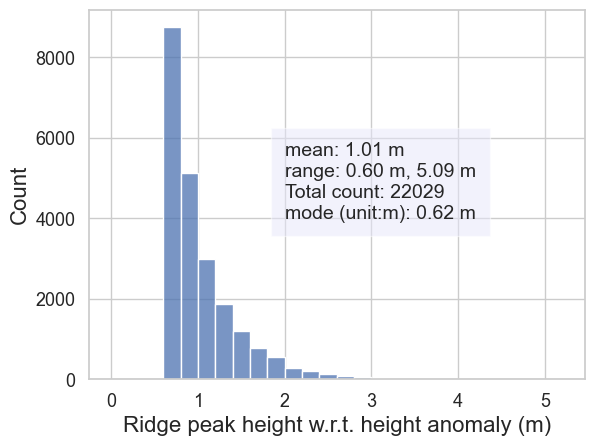

In [508]:
ele_avg = peak_stats_df["relative elevation"].mean() ## average relative height
ele_max = peak_stats_df["relative elevation"].max()
ele_min = peak_stats_df["relative elevation"].min()
ele_mode = peak_stats_df["relative elevation"].round(2).mode()
ele_count = len(peak_stats_df)
# print(np.count_nonzero(elev == 0))

ele_stats = "mean: " + f"{ele_avg:.2f}" + ' m\nrange: ' + f"{ele_min:.2f}" + " m, " +  f"{ele_max:.2f}"+" m\nTotal count: " + str(ele_count)
ele_stats = ele_stats + "\nmode (unit:m): " + str(ele_mode.values[0]) +" m"
print(ele_stats)

sns.set(style="whitegrid")
ax = sns.histplot(peak_stats_df["relative elevation"], binwidth = 0.2, binrange = [0, 5.2])
ax.text(2, 4000, ele_stats, bbox={'facecolor': 'lavender', 'alpha': 0.5, 'pad': 10}, fontsize = 14)
plt.ylabel("Count", fontsize = 16)
plt.xlabel(r"Ridge peak height w.r.t. height anomaly (m)", fontsize = 16)
plt.tick_params(axis='y', labelsize=13.0)
plt.tick_params(axis='x', labelsize=13.0)

## Below plots have excluded ridges with 0 length

mean: 1.02 m
range: 0.60 m, 5.09 m
Total count: 21302
mode (unit:m): 0.62 m


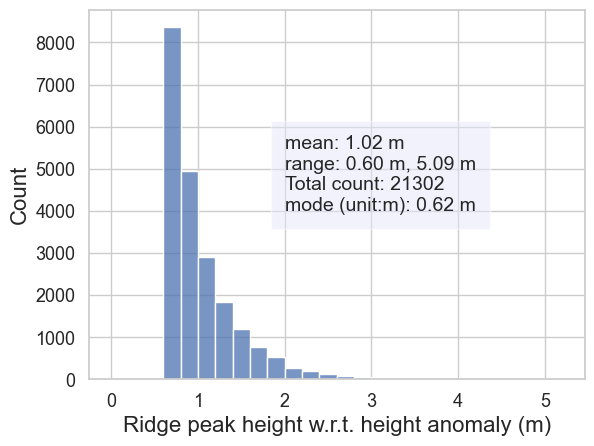

In [507]:
ele_avg = length_stats_df["relative elevation"].mean() ## average relative height
ele_max = length_stats_df["relative elevation"].max()
ele_min = length_stats_df["relative elevation"].min()
ele_mode = length_stats_df["relative elevation"].round(2).mode()
ele_count = len(length_stats_df)

ele_stats = "mean: " + f"{ele_avg:.2f}" + ' m\nrange: ' + f"{ele_min:.2f}" + " m, " +  f"{ele_max:.2f}"+" m\nTotal count: " + str(ele_count)
ele_stats = ele_stats + "\nmode (unit:m): " + str(ele_mode.values[0]) +" m"
print(ele_stats)

sns.set(style="whitegrid")
ax = sns.histplot(length_stats_df["relative elevation"], binwidth = 0.2, binrange = [0, 5.2])
ax.text(2, 4000, ele_stats, bbox={'facecolor': 'lavender', 'alpha': 0.5, 'pad': 10}, fontsize = 14)
plt.ylabel("Count", fontsize = 16)
plt.xlabel(r"Ridge peak height w.r.t. height anomaly (m)", fontsize = 16)
plt.tick_params(axis='y', labelsize=13.0)
plt.tick_params(axis='x', labelsize=13.0)

mean: 48.38 m
range: 0.14 m, 1174.60 m
Total count: 21302
mode (unit:m): 0.85 m


Text(150, 4000, 'mean: 48.38 m\nrange: 0.14 m, 1174.60 m\nTotal count: 21302\nmode (unit:m): 0.85 m')

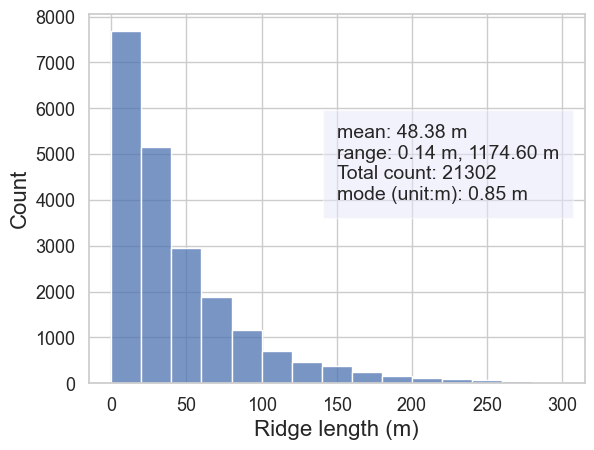

In [504]:
# peak_stats_df["length (km)"] =  peak_stats_df["length"]/1000 
length_stats_df = peak_stats_df.loc[peak_stats_df["length"] > 0]
len_avg = length_stats_df["length"].mean() ## average relative height
len_max = length_stats_df["length"].max()
len_min = length_stats_df["length"].min()
len_mode = length_stats_df["length"].round(2).mode()
len_count = len(length_stats_df)

len_stats = "mean: " + f"{len_avg:.2f}" + ' m\nrange: ' + f"{len_min:.2f}" + " m, " +  f"{len_max:.2f}"+" m\nTotal count: " + str(len_count)
len_stats = len_stats + "\nmode (unit:m): " + str(len_mode.values[0]) +" m"
print(len_stats)
sns.set(style="whitegrid")
ax = sns.histplot(length_stats_df["length"], binwidth = 20, binrange = [0, 300])
plt.ylabel("Count", fontsize = 16)
plt.xlabel(r"Ridge length (m)", fontsize = 16)
plt.tick_params(axis='y', labelsize=13.0)
plt.tick_params(axis='x', labelsize=13.0)
ax.text(150, 4000, len_stats, bbox={'facecolor': 'lavender', 'alpha': 0.5, 'pad': 10}, fontsize = 14)


Ridges longer than 300m
mean: 415.02 m
range: 300.06 m, 1174.60 m
Total count: 182
mode (unit:m): 351.82 m


Text(600, 40, 'Ridges longer than 300m\nmean: 415.02 m\nrange: 300.06 m, 1174.60 m\nTotal count: 182\nmode (unit:m): 351.82 m')

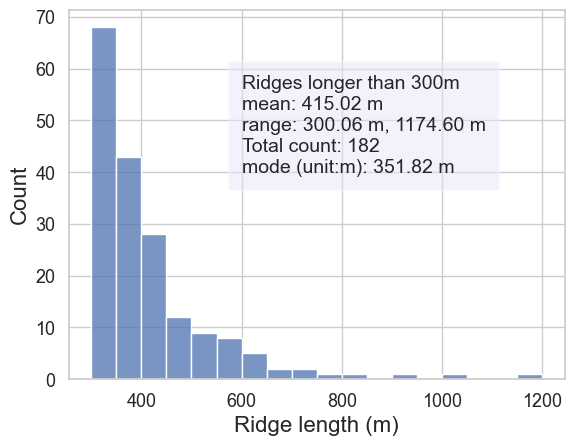

In [503]:
longer_ridges = peak_stats_df.loc[peak_stats_df["length"] >= 300]
len_avg = longer_ridges["length"].mean() ## average relative height
len_max = longer_ridges["length"].max()
len_min = longer_ridges["length"].min()
len_mode = longer_ridges["length"].round(2).mode()
len_count = len(longer_ridges)
# print(np.count_nonzero(elev == 0))

len_stats = "Ridges longer than 300m\n"+"mean: " + f"{len_avg:.2f}" + ' m\nrange: ' + f"{len_min:.2f}" + " m, " +  f"{len_max:.2f}"+" m\nTotal count: " + str(len_count)
len_stats = len_stats + "\nmode (unit:m): " + str(len_mode.values[0]) +" m"
print(len_stats)
sns.set(style="whitegrid")
ax = sns.histplot(peak_stats_df["length"], binwidth = 50, binrange = [300, 1200])
plt.ylabel("Count", fontsize = 16)
plt.xlabel(r"Ridge length (m)", fontsize = 16)
plt.tick_params(axis='y', labelsize=13.0)
plt.tick_params(axis='x', labelsize=13.0)
ax.text(600, 40, len_stats, bbox={'facecolor': 'lavender', 'alpha': 0.5, 'pad': 10}, fontsize = 14)

In [473]:
longer_ridges = peak_stats_df.loc[peak_stats_df["length"] >= 500]
len_avg = longer_ridges["length"].mean() ## average relative height
len_max = longer_ridges["length"].max()
len_min = longer_ridges["length"].min()
len_mode = longer_ridges["length"].round(2).mode()
len_count = len(longer_ridges)
# print(np.count_nonzero(elev == 0))

len_stats = "mean: " + f"{len_avg:.2f}" + ' m\nh range: ' + f"{len_min:.2f}" + " m, " +  f"{len_max:.2f}"+" m\nNo. of measurements: " + str(len_count)
len_stats = len_stats + "\nmode (unit:m): " + str(len_mode.values[0]) +" m"
print(len_stats)

mean: 644.26 m
h range: 509.54 m, 1174.60 m
No. of measurements: 31
mode (unit:m): 509.54 m
